In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling
from rasterio.plot import show
from skimage.draw import line
from rasterio import open as rio_open
from scipy.signal import savgol_filter
from PIL import Image
import pandas as pd
import matplotlib as mpl

In [2]:
# Function to read the image using rasterio
def read_image(tif_path):
    #with rasterio.open(image_path) as dataset:
    with rasterio.open(tif_path) as src:
        image = src.read(1)
        transform = src.transform  # Get geotransform
        crs = src.crs  # Get coordinate reference system
        bounds = src.bounds  # Get bounding box
    return image, transform, crs, bounds


def extract_line_profile(tif_path, start_point_geo, end_point_geo, plot_line=True):
    """
    Extract the profile line from a TIFF file and optionally plot the line on the image.
    
    Parameters:
        tif_path (str): Path to the TIFF file.
        start_point_geo (tuple): Starting point in georeferenced coordinates (easting, northing).
        end_point_geo (tuple): Ending point in georeferenced coordinates (easting, northing).
        plot_line (bool): Whether to plot the line on the image. Default is True.
    
    Returns:
        numpy.ndarray: Pixel values along the profile line.
    """
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the first (or only) band
        transform = src.transform  # Get geotransform
        crs = src.crs  # Get coordinate reference system

    # Convert georeferenced coordinates to pixel coordinates
    start_point_pixel = ~transform * start_point_geo  # (col, row)
    end_point_pixel = ~transform * end_point_geo  # (col, row)
    """
    # Round to nearest integer for pixel indices
    #Rounding to the nearest integer is a critical step when converting 
    georeferenced coordinates to pixel indices. It ensures that:

    # The indices are valid integers.
    
    # The correct pixel is selected.
    
    # No IndexError is raised.
    """
    # Round to nearest integer for pixel indices
    start_point_pixel = (int(round(start_point_pixel[1])), int(round(start_point_pixel[0])))  # (row, col)
    end_point_pixel = (int(round(end_point_pixel[1])), int(round(end_point_pixel[0])))  # (row, col)

    # Get line indices
    rr, cc = line(start_point_pixel[0], start_point_pixel[1], end_point_pixel[0], end_point_pixel[1])

    # Extract pixel values along the line
    profile_values = - band[rr, cc]
    return profile_values

# Function to normalize the image
def normalize(array):
    """
    Normalize an array to the range [0, 1].
    
    Parameters:
        array (numpy.ndarray): Input 2D array.
    
    Returns:
        numpy.ndarray: Normalized array.
    """
    array_min, array_max = array.min(), array.max()
    return (array - array_min) / (array_max - array_min)

# Function to extract profile line values from a raster
def extract_normlized_line_profile(tif_path, start_point_geo, end_point_geo):
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the first (or only) band
        band_norm = 1- normalize(band)
        transform = src.transform  # Get geotransform
        crs = src.crs  # Get coordinate reference system
    # Convert georeferenced coordinates to pixel coordinates
    start_point_pixel = ~transform * start_point_geo  # (col, row)
    end_point_pixel = ~transform * end_point_geo  # (col, row)

    # Round to nearest integer for pixel indices
    start_point_pixel = (int(round(start_point_pixel[1])), int(round(start_point_pixel[0])))  # (row, col)
    end_point_pixel = (int(round(end_point_pixel[1])), int(round(end_point_pixel[0])))  # (row, col)

    # Get line indices
    rr, cc = line(start_point_pixel[0], start_point_pixel[1], end_point_pixel[0], end_point_pixel[1])

    # Extract pixel values along the line
    profile_values = band_norm[rr, cc]
    return profile_values


def smooth_data(data, window_size=101, polyorder=2): 
    return savgol_filter(data, window_size, polyorder)


def process_tif_paths(tif_path, start_point, end_point):
    """
    Processes a list of TIF file paths to extract, invert, smooth,
    and return the line profile data.

    Args:
        tif_paths (list): List of file paths to TIF files.
        start_point (tuple): Starting point for line profile extraction.
        end_point (tuple): Ending point for line profile extraction.

    Returns:
        list: A list of smoothed and inverted line profile values.
    """
     # Extract line profile data
    values = extract_normlized_line_profile(tif_path, start_point, end_point)
    inverted_values = values  # Reverse convexity
    smoothed_values = smooth_data(inverted_values)  # Smooth the data
    return smoothed_values

In [3]:
tif_path_1 = "Normalized_Unw_Phase_ifg_10May2024_21May2024_27N.tif"
tif_path_2 = "Normalized_Unw_Phase_ifg_08Sep2024_13Nov2024_27N.tif"

In [4]:
# Open the first GeoTIFF
with rasterio.open(tif_path_1) as src1:
    image1 = src1.read(1)  # Read the first band
    profile1 = src1.profile  # Save the profile for reference

# Open the second GeoTIFF
with rasterio.open(tif_path_2) as src2:
    image2 = src2.read(1)  # Read the first band
    profile2 = src2.profile  # Save the profile for reference

# Check dimensions and reproject if necessary
if image1.shape != image2.shape or profile1['transform'] != profile2['transform']:
    # Create a destination array with the same shape as the first image
    reprojected_image2 = np.empty_like(image1, dtype=image1.dtype)

    # Reproject the second image to match the first
    reproject(
        source=image2,
        destination=reprojected_image2,
        src_transform=profile2['transform'],
        src_crs=profile2['crs'],
        dst_transform=profile1['transform'],
        dst_crs=profile1['crs'],
        resampling=Resampling.nearest
    )
    image2 = reprojected_image2

# Normalize image1 and image2 (assuming they are NumPy arrays after reading)
image1_normalized = (image1 - np.min(image1)) / (np.max(image1) - np.min(image1))
image2_normalized = (image2 - np.min(image2)) / (np.max(image2) - np.min(image2))

# Subtract the normalized images
result = image2_normalized.astype(float) - image1_normalized.astype(float)

In [5]:
# Read metadata (CRS and transform) from an existing reference image
with rasterio.open(tif_path_1) as src:
    crs = src.crs
    transform = src.transform

# Save the normalized result to a GeoTIFF compatible with SNAP
output_file_path= "Normalized_Phase_Difference_08Sep2024_13Nov2024-10May2024_21May2024.tif"

# Save the normalized image as a GeoTIFF
with rasterio.open(
    output_file_path,
    "w",
    driver="GTiff",
    height=result.shape[0],
    width=result.shape[1],
    count=1,  # Single band
    dtype="float32",  # Save as 32-bit floating point
    crs=crs,  # Use the CRS from the original image
    transform=transform  # Use the geotransform from the original image
) as dst:
    # Write the normalized result to the first band
    dst.write(result, 1)

print(f"Normalized image saved at: {output_file_path}")

# Check the min and max values of the normalized result
print(f"Normalized result range: {np.nanmin(result):.1f} to {np.nanmax(result):.1f}")

Normalized image saved at: Normalized_Phase_Difference_08Sep2024_13Nov2024-10May2024_21May2024.tif
Normalized result range: -1.0 to 1.0


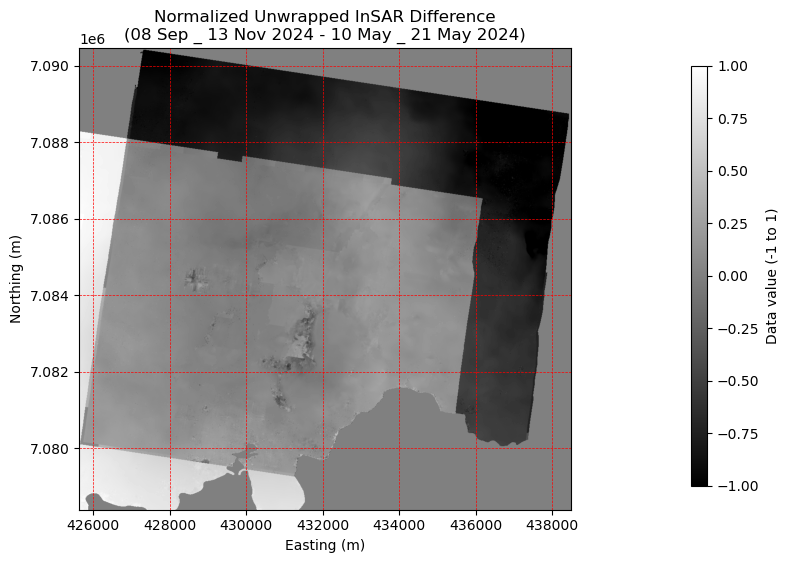

In [6]:
image1 = "Normalized_Phase_Difference_08Sep2024_13Nov2024-10May2024_21May2024.tif"

image1, transform, crs, bounds = read_image(image1)

# Create one figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Use rasterio's show with the axis
img= show(image1, transform=transform, ax=ax, cmap='gray')

# Add labels and title
ax.set_title("Normalized Unwrapped InSAR Difference\n(08 Sep _ 13 Nov 2024 - 10 May _ 21 May 2024)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(color='red', linestyle='--', linewidth=0.5)

# Add colorbar using the image object
# cbar = plt.colorbar(img.get_images()[0], ax=ax, shrink=0.7)
# cbar.set_label("Phase difference (radians)")

# # # Add a second colorbar for normalized data (0 to 1)
cbar_ax1 = fig.add_axes([0.97, 0.15, 0.02, 0.7])  # Position for the second colorbar
global_cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(-1, 1)), cax=cbar_ax1, orientation='vertical')
global_cbar1.set_label("Data value (-1 to 1)")

plt.show()

Start Point (Easting, Northing): (428000, 7086000)
End Point (Easting, Northing): (431000, 7080500)


C:\Users\Mohannad Zahra\AppData\Local\Temp\ipykernel_7976\360530673.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.01, 0.92, 0.98])


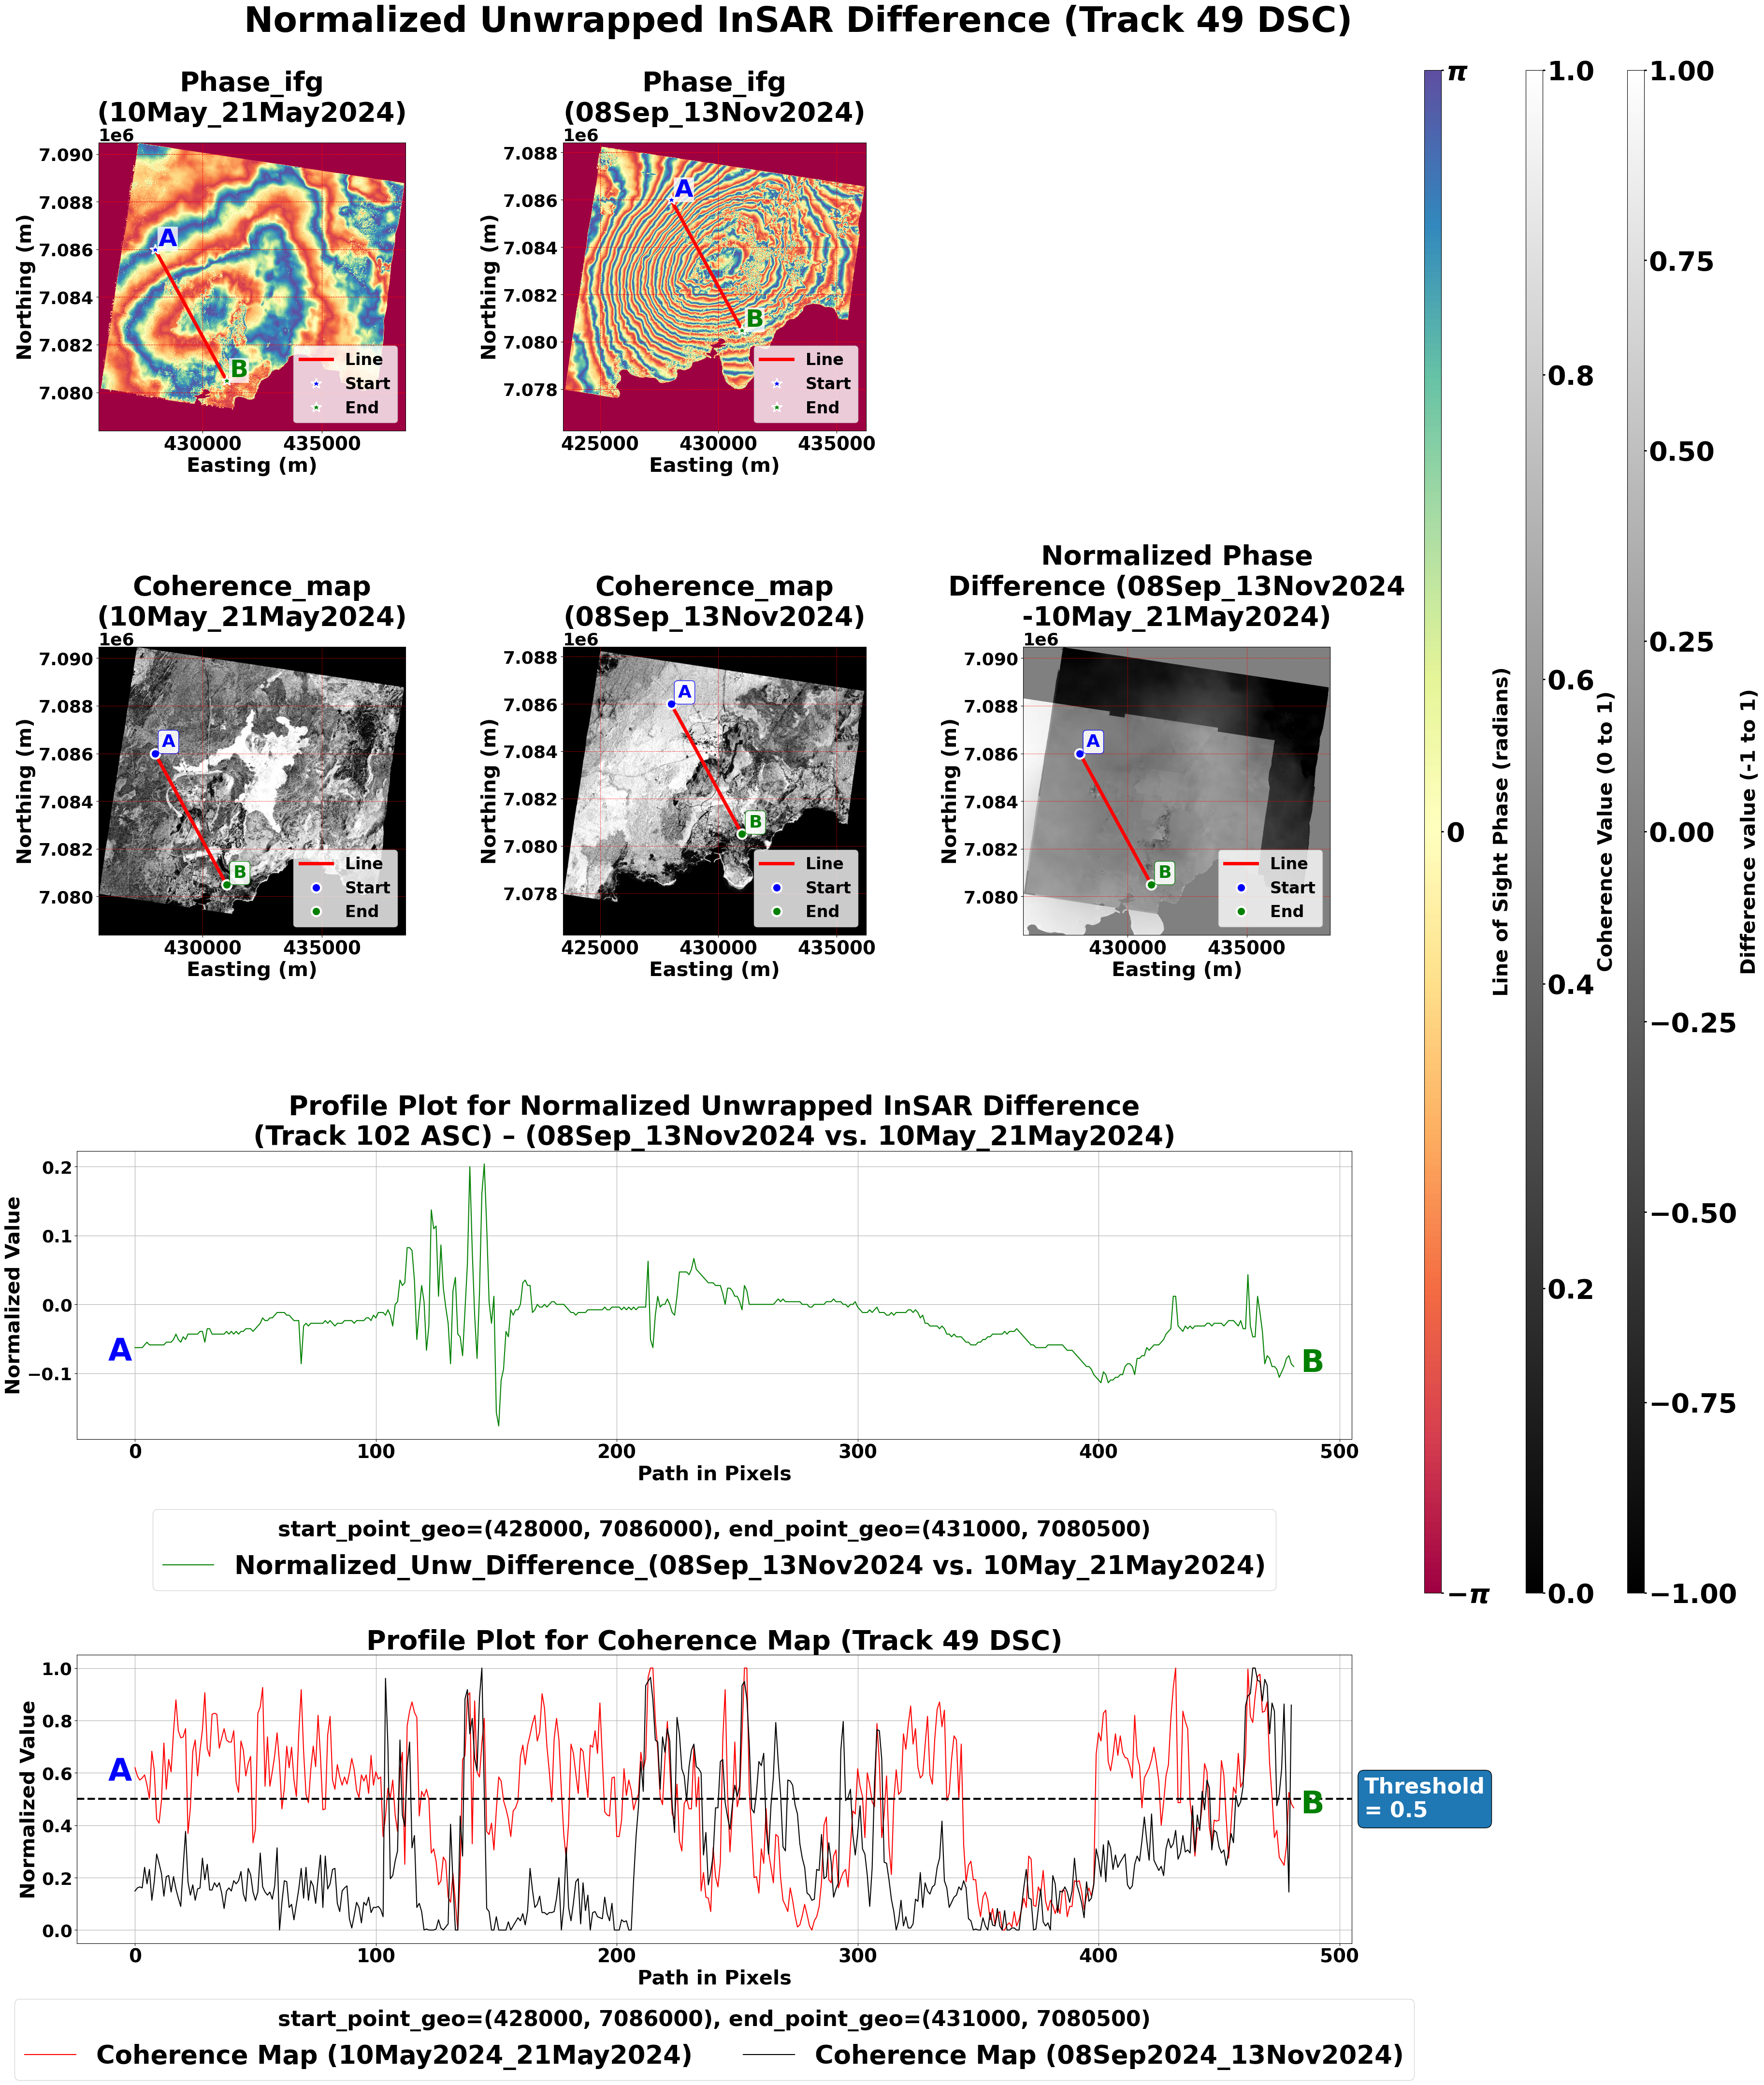

In [19]:
# Read the images
tif_paths = [
    "Phase_ifg_HH_10May2024_21May2024_27N.tif",
    "Phase_ifg_HH_08Sep2024_13Nov2024_27N.tif",
    "coh_HH_10May2024_21May2024_27N.tif",
    "coh_HH_08Sep2024_13Nov2024_27N.tif",
    "Normalized_Phase_Difference_08Sep2024_13Nov2024-10May2024_21May2024.tif"
]
titles = [
    "Phase_ifg\n(10May_21May2024)",
    "Phase_ifg\n(08Sep_13Nov2024)",
    "Coherence_map\n(10May_21May2024)",
    "Coherence_map\n(08Sep_13Nov2024)",
    "Normalized Phase\nDifference (08Sep_13Nov2024\n-10May_21May2024)"
]

# Read the images
images = [read_image(path) for path in tif_paths]

# Define start and end points in georeferenced coordinates (easting, northing)
start_point_geo = (428000, 7086000)  # Example: (easting, northing)
end_point_geo = (431000, 7080500)  # Example: (easting, northing)

# Extract row and column coordinates
rows = [start_point_geo[0], end_point_geo[0]]
cols = [start_point_geo[1], end_point_geo[1]]


print(f"Start Point (Easting, Northing): {start_point_geo}")
print(f"End Point (Easting, Northing): {end_point_geo}")


# Create subplots: Only 2 plots in first row, 3 in second row, and 2 full-width profile plots
fig = plt.figure(figsize=(35, 45))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1])

# Axes definitions
phase_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
gray_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
profile_ax1 = fig.add_subplot(gs[2, :])
profile_ax2 = fig.add_subplot(gs[3, :])

# Reorganize images and titles
color_images = images[:2]  # Phase IFGs
gray_images = images[2:]   # Coherence + Difference
color_titles = titles[:2]
gray_titles = titles[2:]

# First row - Color phase IFGs
for ax, (image, transform, _, _), title in zip(phase_axes, color_images, color_titles):    
    ax.imshow(image, cmap="Spectral", extent=[
        transform[2],
        transform[2] + image.shape[1] * transform[0],
        transform[5] + image.shape[0] * transform[4],
        transform[5]
    ])
    ax.set_title(title,fontsize=40, fontweight='bold')
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.grid(color='red', linestyle='--', linewidth=0.7)
    ax.plot(rows, cols, 'r-', linewidth=5, label="Line")
    ax.plot(rows[0], cols[0], 'b*', markersize=16, markeredgewidth=2, markeredgecolor='w', label="Start")
    ax.annotate('A', xy=(start_point_geo[0], start_point_geo[1]), xytext=(5, 5), 
            textcoords='offset points', fontsize=36, color='b', weight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    ax.plot(rows[1], cols[1], 'g*', markersize=16, markeredgewidth=2, markeredgecolor='w', label="End")
    ax.annotate('B', xy=(end_point_geo[0], end_point_geo[1]), xytext=(5, 5), 
            textcoords='offset points', fontsize=36, color='g', weight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    ax.legend(loc='lower right')

# Second row - Coherence + difference (gray)
for ax, (image, transform, _, _), title in zip(gray_axes, gray_images, gray_titles):    
    ax.imshow(image, cmap="gray", extent=[
        transform[2],
        transform[2] + image.shape[1] * transform[0],
        transform[5] + image.shape[0] * transform[4],
        transform[5]
    ])
    ax.set_title(title,fontsize=40, fontweight='bold')
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.grid(color='red', linestyle='--', linewidth=0.5)
    
    # Enhanced visibility for coherence maps
    ax.plot(rows, cols, 'r-', linewidth=5, label="Line")  # Yellow line for better contrast
    ax.plot(rows[0], cols[0], 'bo', markersize=14, markeredgewidth=3, markeredgecolor='w', label="Start")
    ax.plot(rows[1], cols[1], 'go', markersize=14, markeredgewidth=3, markeredgecolor='w', label="End")
    
    # Enhanced annotations
    ax.annotate('A', xy=(start_point_geo[0], start_point_geo[1]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=26, color='b', weight='bold',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='b', boxstyle='round,pad=0.2'))
    ax.annotate('B', xy=(end_point_geo[0], end_point_geo[1]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=26, color='g', weight='bold',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='g', boxstyle='round,pad=0.2'))
    ax.legend(loc='lower right')

# Colorbars
cbar_ax = fig.add_axes([0.87, 0.25, 0.01, 0.7])
global_cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=-np.pi, vmax=np.pi)), cax=cbar_ax)
global_cbar.set_ticks([-np.pi, 0, np.pi])
global_cbar.set_ticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
global_cbar.set_label("Line of Sight Phase (radians)",fontsize=30, fontweight='bold')
global_cbar.ax.tick_params(labelsize=40, width=2)

cbar_ax1 = fig.add_axes([0.93, 0.25, 0.01, 0.7])
global_cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(0, 1)), cax=cbar_ax1)
global_cbar1.set_label("Coherence Value (0 to 1)",fontsize=30, fontweight='bold')
global_cbar1.ax.tick_params(labelsize=40, width=2)

cbar_ax2 = fig.add_axes([0.99, 0.25, 0.01, 0.7])
global_cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap="gray", norm=plt.Normalize(-1, 1)), cax=cbar_ax2)
global_cbar2.set_label("Difference value (-1 to 1)",fontsize=30, fontweight='bold')
global_cbar2.ax.tick_params(labelsize=40, width=2)


# Title
fig.suptitle("Normalized Unwrapped InSAR Difference (Track 49 DSC)", fontsize=52, fontweight='bold')


tif_path_1 ="Normalized_Phase_Difference_08Sep2024_13Nov2024-10May2024_21May2024.tif"
tif_path_2 = "Normalized_coh_HH_10May2024_21May2024_27N.tif"
tif_path_3 = "Normalized_coh_HH_08Sep2024_13Nov2024_27N.tif"

# Plot profile lines (third and fourth row)
line_values_1 = extract_line_profile(tif_path_1, start_point_geo, end_point_geo)
profile_ax1.plot(range(len(line_values_1)), line_values_1, color='green',
                 label="Normalized_Unw_Difference_(08Sep_13Nov2024 vs. 10May_21May2024)")
profile_ax1.set_title('Profile Plot for Normalized Unwrapped InSAR Difference\n(Track 102 ASC) – (08Sep_13Nov2024 vs. 10May_21May2024)',
          fontsize=40, fontweight='bold')

profile_ax1.annotate('A', xy=(0, line_values_1[0]), xytext=(-40, -20), 
             textcoords='offset points', fontsize=46, fontweight='bold', color='blue')
profile_ax1.annotate('B', xy=(len(line_values_1)-1, line_values_1[-1]), xytext=(10, -8), 
             textcoords='offset points', fontsize=46, fontweight='bold', color='g')

profile_ax1.set_xlabel("Path in Pixels")
profile_ax1.set_ylabel("Normalized Value")
profile_ax1.grid(True)
#profile_ax1.legend(title=f"start_point_geo={start_point_geo}\nend_point_geo={end_point_geo}",frameon=False,fontsize=16)
profile_ax1.legend(
    loc='upper center',
    title=f"start_point_geo={start_point_geo}, end_point_geo={end_point_geo}",
    bbox_to_anchor=(0.5, -0.2),  # X center, Y below the figure
    ncol=2,                       # Spread legend into 3 columns
    fontsize=38
)


line_values_2 = extract_normlized_line_profile(tif_path_2, start_point_geo, end_point_geo)
line_values_3 = extract_normlized_line_profile(tif_path_3, start_point_geo, end_point_geo)

profile_ax2.plot(range(len(line_values_2)), line_values_2, color='red', label="Coherence Map (10May2024_21May2024)")
profile_ax2.plot(range(len(line_values_3)), line_values_3, color='black', label="Coherence Map (08Sep2024_13Nov2024)")

# Add 'A' at the start and 'B' at the end of the profile line
profile_ax2.annotate('A', xy=(0, line_values_2[0]), xytext=(-40, -20), 
             textcoords='offset points', fontsize=46, fontweight='bold', color='blue')
profile_ax2.annotate('B', xy=(len(line_values_2)-1, line_values_2[-1]), xytext=(10, -8), 
             textcoords='offset points', fontsize=46, fontweight='bold', color='g')


profile_ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=3)
profile_ax2.text(1.01, 0.5, 'Threshold\n= 0.5',
                 transform=profile_ax2.transAxes, color='white', fontsize=32,
                 ha='left', va='center', bbox=dict(edgecolor='black', boxstyle='round,pad=0.3'))
profile_ax2.set_title("Profile Plot for Coherence Map (Track 49 DSC)", fontsize=40, fontweight='bold')
profile_ax2.set_xlabel("Path in Pixels")
profile_ax2.set_ylabel("Normalized Value")
profile_ax2.grid(True)
profile_ax2.legend(title=f"start_point_geo={start_point_geo}, end_point_geo={end_point_geo}")#, fontsize=14)
profile_ax2.legend(
    loc='upper center',
    title=f"start_point_geo={start_point_geo}, end_point_geo={end_point_geo}",
    bbox_to_anchor=(0.5, -0.15),  # X center, Y below the figure
    ncol=2,                       # Spread legend into 3 columns
    fontsize=38
)


plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 28,
    'ytick.labelsize': 26,
    'legend.fontsize': 24,
    'figure.titlesize': 42
})

plt.tight_layout(rect=[0.01, 0.01, 0.92, 0.98])

# Save the figure
fig.savefig("Normalized Unwrapped InSAR Difference (Track 49 DSC) – (08Sep_13Nov2024 vs. 10May_21May2024)_map11.png", dpi=300, bbox_inches="tight")

plt.show()